In [1]:
# a & e data are read in from .csv files

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ReadParticle import read_particle
from datetime import datetime, timedelta

# Read particle and collision data
Np_seq, time, N_colDidy, N_colDimor, N_escape, r_dust, particle, data_c, data_p = read_particle('particles.txt', 'collide.txt')

No. 1913 of output frame has been analyzed (100.0%)
optimizing data structure ...
analyzing collision data ...
processing completed!


In [14]:
# Constants
G = 6.6743e-11
mass_system = 5.5e11
sep_system = 1170.0
mu_system = 6.6743e-11 * 5.5e11
vol_didy = 0.2295409644951028e9
vol_dimor = 0.001830603200702610e9
mass_didy = mass_system * vol_didy / (vol_didy + vol_dimor)
mass_dimor = mass_system * vol_dimor / (vol_didy + vol_dimor)

r_dimor_com = vol_didy*sep_system/(vol_didy+vol_dimor)
v_dimor_com = -np.sqrt(G*mass_didy/sep_system**2*r_dimor_com)
v_dimor_com

-0.17572821136485348

# Plotting ejecta type ...


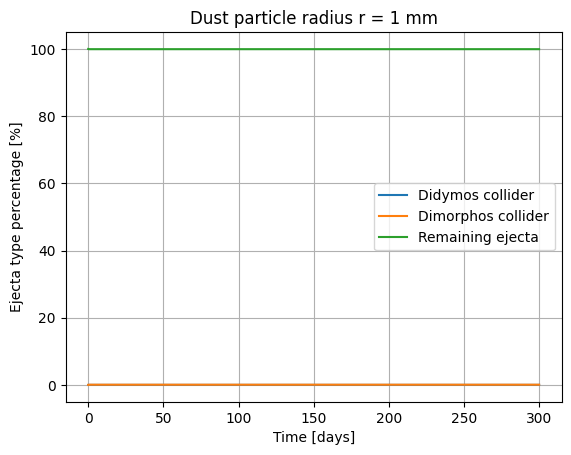

# Ejecta type completed!



In [2]:
# Plotting ejecta type
if (1):
    print("# Plotting ejecta type ...",flush=True)
    plt.figure()
    plt.plot(np.append(np.insert(N_colDidy[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDidy[:,1],0,0),N_colDidy[-1,1]) / Np_seq[0] * 100,
             label='Didymos collider', linewidth=1.5)
    plt.plot(np.append(np.insert(N_colDimor[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDimor[:,1],0,0),N_colDimor[-1,1]) / Np_seq[0] * 100,
             label='Dimorphos collider', linewidth=1.5)
    # plt.plot(np.append(np.insert(N_escape[:,0],0,0),time[-1]) / 24 / 3600,
    #          np.append(np.insert(N_escape[:,1],0,0),N_escape[-1,1]) / Np_seq[0] * 100,
    #          label='Escaped ejecta', linewidth=1.5)
    #plt.plot(np.insert(time_sort, 0, 0) / 24 / 3600, np.insert(N_sort, 0, 0) / Np_seq[0] * 100, label='Escaped ejecta', linewidth=1.5)
    plt.plot(time / 24 / 3600,
             Np_seq / Np_seq[0] * 100,
             label='Remaining ejecta', linewidth=1.5)
    plt.xlabel('Time [days]')
    plt.ylabel('Ejecta type percentage [%]')
    plt.title('Dust particle radius r = 1 mm')
    plt.legend()
    plt.grid()
    plt.savefig('ejecta_type.png',dpi=300)
    plt.show()
    plt.close()
    print("# Ejecta type completed!\n",flush=True)

# Plotting Dimorphos orbit ...


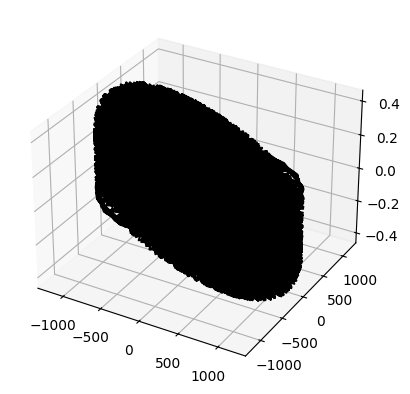

# Dimorphos orbit completed!



In [8]:
# Dimorphos orbit
if (1):
    print("# Plotting Dimorphos orbit ...",flush=True)
    didy_pos  = particle[0]['pos']
    dimor_pos = particle[1]['pos']
    n_p = 10
    np_pos    = particle[n_p]['pos']

    plt.figure().add_subplot(projection='3d')
    plt.plot(dimor_pos[:, 0] - didy_pos[:, 0],
             dimor_pos[:, 1] - didy_pos[:, 1],
             dimor_pos[:, 2] - didy_pos[:, 2], 
             label = 'Dimorphos orbit', linewidth=1.5, color='k')
    #plt.plot(np_pos[:, 0] - didy_pos[0:len(np_pos), 0],
    #         np_pos[:, 1] - didy_pos[0:len(np_pos), 1],
    #         np_pos[:, 2] - didy_pos[0:len(np_pos), 2],
    #         label = f'particle {n_p} orbit', linewidth=1.5)
    plt.savefig('dimor_orbit.png',dpi=300)
    plt.show()
    plt.close()
    print("# Dimorphos orbit completed!\n",flush=True)

In [123]:
"""phase angle analysis"""

import os
from multiprocessing import Pool
import numpy as np
from frame_renderer import init_worker, render_phase_angle_histogram

# Ensure output directory exists for saving frames
output_dir = "phase_angle"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)

if __name__ == "__main__": 
    # Render frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, 0, output_dir)) as pool:
        pool.map(render_phase_angle_histogram, range(num_frames))
    print(f"Frames rendered and saved in {output_dir}.")

Frames rendered and saved in phase_angle. 1847...dering phase angle histogram for frame 8...Rendering phase angle histogram for frame 16...Rendering phase angle histogram for frame 32...Rendering phase angle histogram for frame 24...Rendering phase angle histogram for frame 40...Rendering phase angle histogram for frame 48...Rendering phase angle histogram for frame 56...Rendering phase angle histogram for frame 72...Rendering phase angle histogram for frame 64...Rendering phase angle histogram for frame 120...Rendering phase angle histogram for frame 104...Rendering phase angle histogram for frame 128...Rendering phase angle histogram for frame 136...Rendering phase angle histogram for frame 184...Rendering phase angle histogram for frame 168...Rendering phase angle histogram for frame 176...Rendering phase angle histogram for frame 200...Rendering phase angle histogram for frame 192...Rendering phase angle histogram for frame 232...Rendering phase angle histogram for frame 216...Rend

In [6]:
"""Top view Parallel rendering and make video"""

import os
from multiprocessing import Pool
import numpy as np
from frame_renderer import init_worker, render_frame_topview

# Ensure output directory exists for saving frames
output_dir = "topview_frames"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)
fps = 10
zmout_freq = 300
output_name = "topview_dusts.mp4"

# set the plot axis limit for each frame
axis_lim_list = []
for i in range(num_frames): # Must be executed sequentially 
    if i%zmout_freq==0:
        data_i = data_p[i]
        dust_distance = (data_i[4:, 1]**2 + data_i[4:, 2]**2 + data_i[4:, 3]**2)**0.5
        dis_max = dust_distance.max()
        axis_lim_list.append(dis_max)
        cache1 = dis_max
    else:
        axis_lim_list.append(cache1)
#axis_lim_list = np.array(axis_lim_list)

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, axis_lim_list, output_dir)) as pool:
        pool.map(render_frame_topview, range(num_frames))
    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation saved as {output_name}",flush=True)

All frames rendered. Combining into video...dering frame 24...Rendering frame 0...Rendering frame 32...Rendering frame 40...Rendering frame 64...Rendering frame 48...Rendering frame 56...Rendering frame 80...Rendering frame 72...Rendering frame 88...Rendering frame 104...Rendering frame 96...Rendering frame 128...Rendering frame 120...Rendering frame 112...Rendering frame 136...Rendering frame 144...Rendering frame 216...Rendering frame 224...Rendering frame 232...Rendering frame 248...Rendering frame 240...Rendering frame 200...Rendering frame 256...Rendering frame 272...Rendering frame 208...Rendering frame 264...Rendering frame 280...Rendering frame 304...Rendering frame 320...Rendering frame 344...Rendering frame 336...Rendering frame 360...Rendering frame 368...Rendering frame 376...Rendering frame 392...Rendering frame 408...Rendering frame 424...Rendering frame 416...Rendering frame 440...Rendering frame 432...Rendering frame 448...Rendering frame 464...Rendering frame 456...Ren

ffmpeg version 4.2.9 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -g -pipe -Wall -Werror=format-security -Wp,-D_FORTIFY_SOURCE=2 -Wp,-D_GLIBCXX_ASSERTIONS -fexceptions -fstack-protector-strong -grecord-gcc-switches -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection' --extra-ldflags='-Wl,-z,relro -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld ' --extra-cflags=' ' --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libvo-amrwbenc --enable-version3 --enable-bzlib --disable-crystalhd --enable-fontconfig --enable-frei0r --enable-gcrypt --enable-gnutls --enable-ladspa --enable-libaom --enable-libdav1d --enabl

Animation saved as topview_dusts.mp4


frame= 1940 fps= 49 q=-1.0 Lsize=   13833kB time=00:03:13.70 bitrate= 585.0kbits/s speed=4.91x    
video:13810kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.166683%
[libx264 @ 0x56041840af80] frame I:8     Avg QP: 3.88  size: 86764
[libx264 @ 0x56041840af80] frame P:607   Avg QP:12.98  size: 13017
[libx264 @ 0x56041840af80] frame B:1325  Avg QP:21.24  size:  4185
[libx264 @ 0x56041840af80] consecutive B-frames:  6.6%  6.3%  2.2% 84.9%
[libx264 @ 0x56041840af80] mb I  I16..4: 77.9% 15.5%  6.6%
[libx264 @ 0x56041840af80] mb P  I16..4:  0.5%  0.1%  0.2%  P16..4:  2.2%  0.6%  0.5%  0.0%  0.0%    skip:95.9%
[libx264 @ 0x56041840af80] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  1.6%  0.3%  0.2%  direct: 0.2%  skip:97.6%  L0:45.6% L1:45.6% BI: 8.8%
[libx264 @ 0x56041840af80] 8x8 transform intra:14.2% inter:8.4%
[libx264 @ 0x56041840af80] coded y,uvDC,uvAC intra: 11.8% 14.2% 13.5% inter: 0.6% 0.4% 0.3%
[libx264 @ 0x56041840af80] i16 v,h,dc,p: 84% 15%  2%  0%
[l

In [15]:
"""Top view single frame"""

from frame_renderer import init_worker, render_frame_topview

# Ensure output directory exists for saving frames
output_dir = "output_singleframe"
os.makedirs(output_dir, exist_ok=True)

# parameters
axis_lim = 40e3  # m
frame = 10

# pass global variables
init_worker(data_p, time, axis_lim, output_dir)
# make plot for single frame
render_frame_topview(frame)

'output_singleframe/frame_0010.png'

Text(0, 0.5, 'axis limit (m)')

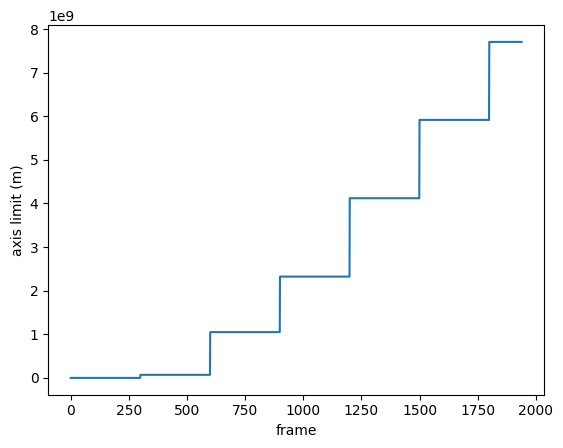

In [7]:
# visualize how axis limit changes with frames
plt.plot(axis_lim_list)
plt.xlabel('frame')
plt.ylabel('axis limit (m)')

In [13]:
"""HST view parallel rendering and make video"""

import os
import numpy as np
from multiprocessing import Pool
from frame_renderer import init_worker, render_frame_HSTview

# Ensure output directory exists for saving frames
output_dir = "HST_frames"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)
fps = 10
zmout_freq = 300
output_name = "HST_view.mp4"

# set the plot axis limit for each frame
axis_lim_list = []
for i in range(num_frames): # Must be executed sequentially 
    if i%zmout_freq==0:
        data_i = data_p[i]
        dust_distance = (data_i[4:, 1]**2 + data_i[4:, 2]**2 + data_i[4:, 3]**2)**0.5
        dis_max = dust_distance.max()
        axis_lim_list.append(dis_max)
        cache1 = dis_max
    else:
        axis_lim_list.append(cache1)

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool(initializer=init_worker, initargs=(data_p, time, axis_lim_list, output_dir)) as pool:
        pool.map(render_frame_HSTview, range(num_frames))
    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation of HSTview saved as {output_name}",flush=True)

All frames rendered. Combining into video...ering frame 24...Rendering frame 16...Rendering frame 48...Rendering frame 32...Rendering frame 40...Rendering frame 56...Rendering frame 64...Rendering frame 80...Rendering frame 72...Rendering frame 88...Rendering frame 96...Rendering frame 104...Rendering frame 120...Rendering frame 136...Rendering frame 152...Rendering frame 168...Rendering frame 176...Rendering frame 192...Rendering frame 232...Rendering frame 184...Rendering frame 280...Rendering frame 264...Rendering frame 288...Rendering frame 304...Rendering frame 312...Rendering frame 320...Rendering frame 336...Rendering frame 328...Rendering frame 352...Rendering frame 360...Rendering frame 368...Rendering frame 384...Rendering frame 392...Rendering frame 400...Rendering frame 416...Rendering frame 440...Rendering frame 448...Rendering frame 464...Rendering frame 472...Rendering frame 496...Rendering frame 504...Rendering frame 273...Rendering frame 225...Rendering frame 417...Ren

ffmpeg version 4.2.9 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -g -pipe -Wall -Werror=format-security -Wp,-D_FORTIFY_SOURCE=2 -Wp,-D_GLIBCXX_ASSERTIONS -fexceptions -fstack-protector-strong -grecord-gcc-switches -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection' --extra-ldflags='-Wl,-z,relro -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld ' --extra-cflags=' ' --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libvo-amrwbenc --enable-version3 --enable-bzlib --disable-crystalhd --enable-fontconfig --enable-frei0r --enable-gcrypt --enable-gnutls --enable-ladspa --enable-libaom --enable-libdav1d --enabl

Animation of HSTview saved as HST_view.mp4


frame= 1940 fps= 61 q=-1.0 Lsize=   12090kB time=00:03:13.70 bitrate= 511.3kbits/s speed=6.04x    
video:12067kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.192729%
[libx264 @ 0x55d101686b00] frame I:9     Avg QP: 2.63  size: 65653
[libx264 @ 0x55d101686b00] frame P:553   Avg QP:15.02  size: 11776
[libx264 @ 0x55d101686b00] frame B:1378  Avg QP:23.14  size:  3812
[libx264 @ 0x55d101686b00] consecutive B-frames:  3.9%  3.0%  3.4% 89.7%
[libx264 @ 0x55d101686b00] mb I  I16..4: 86.9%  7.3%  5.8%
[libx264 @ 0x55d101686b00] mb P  I16..4:  0.5%  0.3%  0.5%  P16..4:  2.4%  0.5%  0.5%  0.0%  0.0%    skip:95.3%
[libx264 @ 0x55d101686b00] mb B  I16..4:  0.0%  0.0%  0.1%  B16..8:  1.7%  0.4%  0.3%  direct: 0.1%  skip:97.4%  L0:49.4% L1:45.3% BI: 5.3%
[libx264 @ 0x55d101686b00] 8x8 transform intra:14.5% inter:10.5%
[libx264 @ 0x55d101686b00] coded y,uvDC,uvAC intra: 14.5% 0.9% 0.7% inter: 0.5% 0.1% 0.1%
[libx264 @ 0x55d101686b00] i16 v,h,dc,p: 86% 13%  1%  0%
[li

In [16]:
"""HST view single frame"""

from frame_renderer import init_worker, render_frame_HSTview

# Ensure output directory exists for saving frames
output_dir = "output_singleframe"
os.makedirs(output_dir, exist_ok=True)

# parameters
axis_lim = 40e3  # m
frame = 10

# pass global variables
init_worker(data_p, time, axis_lim, output_dir)
# make plot for single frame
render_frame_HSTview(frame)

'output_singleframe/frame_0010.png'

In [11]:
# a & e analysis

# specify timeslices to be analyzed
orbit_files = ['a_e_t0.csv','a_e_t12969701.csv','a_e_t25920000.csv']

for ofile in orbit_files:
    # processing
    t = ofile.split('t')[1].replace('.csv','')
    ae_array = np.genfromtxt(ofile,delimiter=',',skip_header=1)
    num_rows = np.shape(ae_array)[0]
    # add a fate column to the array of a_e data
    fate_column = np.zeros(num_rows)
    for i in range(num_rows):
        p_id = int(ae_array[i,0])
        p_fate = particle[p_id-1]['id_collide']
        fate_column[i] = p_fate
    ae_array = np.column_stack((ae_array,fate_column))
    
    # select rows of the three main bodies and dust particles
    p0 = ae_array[0]    # the row  of Didymos        in ae_array
    p1 = ae_array[1]    # the row  of Dimorphos      in ae_array
    p2 = ae_array[2]    # the row  of Sun            in ae_array
    p_ae = ae_array[4:] # the rows of dust particles in ae_array

    # Scatter plot with eccentricity shown in color 
    if (1):
        print("# Plotting particle locations with eccentricity ...",flush=True)
        
        # select particles with limited eccentricity and spatial range
        data1 = p_ae[p_ae[:,2]<=10.,:] # select particles with eccentricity <= 5. Don't plot others
        data2 = data1[(data1[:, 5] >= -10) & (data1[:, 5] <= 10), :] # select particles located within certain z range. Don't plot others
        
        plt.figure()
        # plot Dimorphos (x,y)
        #plt.scatter(p0[3], p0[4], c='red', s=10, zorder=3)
        plt.scatter(p1[3], p1[4], c='red', s=8, zorder=3)
        # plot dust particles (x,y), color as eccentricity
        dust_sc = plt.scatter(data1[3:, 3], data1[3:, 4], c=data1[3:, 2], s=2, cmap='gist_rainbow')
        cb = plt.colorbar(dust_sc)
        cb.set_label(f'Eccentricity', fontsize=12)
        
        plt.xlabel('x / m')
        plt.ylabel('y / m')
        plt.axis('equal')
        plt.title(f't = {t} s')
        plt.grid()
        plt.savefig(f'location_e_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Plotting particle locations with eccentricity completed!\n",flush=True)
    
    # Dust fate distribution in a and e space
    if (1):
        print("# Plotting dust fate distribution in a and e space ...",flush=True)
        plt.figure(figsize=(6,4))
        if p_ae[p_ae[:,-1] == 0].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 0,2], p_ae[p_ae[:,-1] == 0,1], s=5, label='Remaining')
        if p_ae[p_ae[:,-1] == 1].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 1,2], p_ae[p_ae[:,-1] == 1,1], s=5, label='Didy_col')
        if p_ae[p_ae[:,-1] == 2].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 2,2], p_ae[p_ae[:,-1] == 2,1], s=5, label='Dimor_col')
        if p_ae[p_ae[:,-1] == 3].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 3,2], p_ae[p_ae[:,-1] == 3,1], s=5, label='Escaped')
        #plt.title('Dust particle radius r = 1 mm')
        plt.xlabel('Eccentricity',size=12)
        plt.ylabel('Semimajor axis [m]',size=12)
        plt.legend(fontsize=10)
        plt.savefig(f'dustfate_ae_{t}s.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Dust fate distribution in a and e space completed!\n",flush=True)

    # Histogram for semi-major axis
    if (1):
        print("# Plotting histogram for semimajor axis ...",flush=True)
        bins = np.linspace(-100,11000,112)  # set bins for semimajor axis
        yscale_type = 'log'

        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,1], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Semimajor axis [m]')
        plt.ylabel('Number')
        plt.savefig(f'semimajor_axis_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))
        
        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,1], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,1], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,1], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,1], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Semimajor axis [m]' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'semimajor_axis_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for semimajor axis completed!\n",flush=True)

    # Histogram for eccentricity
    if (1):
        print("# Plotting histogram for eccentricity ...",flush=True)
        bins = np.linspace(-1,20,150)  # set bins for eccentricity
        yscale_type = 'log'
        
        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,2], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Eccentricity')
        plt.ylabel('Number')
        plt.savefig(f'eccentricity_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))

        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,2], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,2], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,2], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,2], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Eccentricity' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'eccentricity_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for eccentricity completed!\n",flush=True)

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...
# Histogram for eccentricity completed!

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...


/tmp/ipykernel_33215/487134157.py:132: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale(yscale_type)
/tmp/ipykernel_33215/487134157.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1,1].set_yscale(yscale_type)


# Histogram for eccentricity completed!

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...
# Histogram for eccentricity completed!

